# OpenScope's Vismo Dataset

It is essential for animals to detect the presence of predators or prey, even while they move themselves. Relative motion between a visual figure (e.g., predator or prey) and the background is  therefore a highly relevant stimulus in the visual domain. Motion processing has been studied extensively in non-human primates and humans, typically using random dot stimuli. Much less is known about the neural basis of cortical motion processing in mice and about figure-ground interactions in particular, although they offer much better access to studies of the underlying cortical circuits. 

For grating stimuli, recent studies in mice have highlighted the role of interneurons in shaping center-surround interactions in the primary visual cortex (V1). Somatostatin cells (SSTs) mediate suppressive surrounds of pyramidal cells (PCs), with this suppression being reduced or abolished by changes in the orientation of the surround relative to the center. VIP interneurons (VIPs), targeting SSTs, play a role in this modulation. The balance between SSTs and VIPs determines whether the surround has a suppressive or reinforcing effect in V1. Whether a similar circuit also mediates center-surround computations in other stimulus dimensions, such as visual motion, or in other brain regions remains unclear. 

In primates, higher visual areas (MT and MST) exhibit selectivity for motion direction, motion coherence, and strong center-surround interactions. Interestingly, reinforcing and suppressive surrounds are clustered into wide-field and local motion columns, respectively, in primate MT. 
In mice, comparatively little is known about motion processing. V1 is necessary to discriminate different motion directions, but specific higher visual areas are particularly informative about visual motion and sensitive to coherent motion stimuli, pointing at reinforcing surrounds (integration), whereas V1 is often suppressed by these spatially extensive displays. 

For this OpenScope experiments, we aimed to characterize the tuning of six different visual cortical regions (VISp, VISl, VISal, VISrl, VISam, and VISpm) and 4 different cell types (PCs, PV, SST, and VIP) to random-dot kinematograms (RDKs) of different directions, different coherence levels, and different offsets between local/center and global/surround motion. We developed a stimulus to explore motion processing using RDKs for isolating motion selectivity without confounds through orientation selectivity. 
The main stimulus set consisted of white RDKs on a black background with a fixed density, size, speed, and infinite lifetime of dots. A central area of ~25° is defined as the "center" and the rest of the screen is the “surround”. The stimulus set includes variations of 8 center directions, 4 surround directions, their relative offset angle, and RDK-coherence level. The display is on for 1. s with an intertrial interval of 0.5 s. This stimulus set is repeated in random order for trial-averaging. 

We also include receptive field mapping with 20° Gabors to be able to determine units with receptive fields in the center region, as well as a set of drifting gratings at 8 directions for comparison. We also include a period of a blank, isoluminant gray screen for determining spontaneous activity levels. 



### Environment Setup
⚠️**Note: If running on a new environment, run this cell once and then restart the kernel**⚠️

In [37]:
import warnings
warnings.filterwarnings('ignore')

try:
    from databook_utils.dandi_utils import dandi_download_open
except:
    !git clone --depth 1 https://github.com/AllenInstitute/openscope_databook.git
    %cd openscope_databook
    %pip install -e .
    %cd docs/projects

In [38]:
import os

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from scipy import interpolate
from scipy.stats import mannwhitneyu
from math import ceil

%matplotlib inline

### The Experiment
As shown in the metadata table below, Openscope's Vismo Experiment has produced 77 files on the [DANDI Archive](http://dandiarchive.org), with 9 males and 3 females which all have wildtype genotypes. This table was generated from [Getting Experimental Metadata from DANDI](../basics/get_dandiset_metadata.ipynb).

In [39]:
session_files = pd.read_csv("../../data/vismo_sessions.csv")
session_files

,Unnamed: 0,identifier,size,path,session_time,sub_name,session_id,sub_sex,sub_age,sub_genotype,stim_types,#_rois,session_end
0,0,615f0764-e10d-47c6-9d16-bfb89efd6bea,738573559,sub-799426/sub-799426_ses-multiplane-ophys-799...,2025-08-08 14:08:47.039171-07:00,799426,multiplane-ophys_799426_2025-08-08_14-08-47,M,P133D,Sst-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt,"{'rdkCircle_presentations', 'drifting_gratings...",327,4147.720290
1,1,18524890-2b79-415a-81e1-130fde7e6c4c,491321749,sub-790102/sub-790102_ses-multiplane-ophys-790...,2025-07-08 11:31:55.618585-07:00,790102,multiplane-ophys_790102_2025-07-08_11-31-55,M,P159D,Pvalb-IRES-Cre/wt;Ai162(TIT2L-GC6s-ICL-tTA2)/wt,"{'rdkCircle_presentations', 'drifting_gratings...",192,4148.368920
2,2,212fc358-4519-46eb-9707-a7df67f7346f,354228125,sub-790107/sub-790107_ses-multiplane-ophys-790...,2025-06-25 09:36:06.965518-07:00,790107,multiplane-ophys_790107_2025-06-25_09-36-06,F,P146D,Pvalb-IRES-Cre/wt;Ai162(TIT2L-GC6s-ICL-tTA2)/wt,"{'rdkCircle_presentations', 'drifting_gratings...",110,4147.878844
3,3,46f94857-c6f4-49f4-aba5-c1c95ac70dda,1735090837,sub-778655/sub-778655_ses-multiplane-ophys-778...,2025-04-26 10:20:16.775341-07:00,778655,multiplane-ophys_778655_2025-04-26_10-20-16,M,P159D,Slc17a7-IRES2-Cre/wt;Camk2a-tTA/wt;Ai93(TITL-G...,"{'rdkCircle_presentations', 'drifting_gratings...",871,4147.720370
4,4,ecce1bc1-5a6f-4c55-b595-320f5cf77aaa,872375880,sub-789166/sub-789166_ses-multiplane-ophys-789...,2025-06-23 09:59:26.277616-07:00,789166,multiplane-ophys_789166_2025-06-23_09-59-26,F,P149D,Vip-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt,"{'rdkCircle_presentations', 'drifting_gratings...",400,4147.358980
...,...,...,...,...,...,...,...,...,...,...,...,...,...
72,72,2b3e42b4-9041-4fe5-b720-f2ee6e7b5216,708565128,sub-774619/sub-774619_ses-multiplane-ophys-774...,2025-04-02 12:25:08.149832-07:00,774619,multiplane-ophys_774619_2025-04-02_12-25-08,M,P156D,Vip-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt,"{'rdkCircle_presentations', 'drifting_gratings...",293,4148.041958
73,73,376d0585-c348-444f-9630-61d7512a4063,1661198875,sub-784498/sub-784498_ses-multiplane-ophys-784...,2025-05-03 10:37:13.827934-07:00,784498,multiplane-ophys_784498_2025-05-03_10-37-13,F,P129D,Slc17a7-IRES2-Cre/wt;Camk2a-tTA/wt;Ai93(TITL-G...,"{'rdkCircle_presentations', 'drifting_gratings...",785,4147.231091
74,74,82366877-a4a9-4f6f-8519-c12da91d01cf,1610864225,sub-762077/sub-762077_ses-multiplane-ophys-762...,2025-03-06 11:49:34.956114-08:00,762077,multiplane-ophys_762077_2025-03-06_11-49-34,M,P196D,Slc17a7-IRES2-Cre/wt;Camk2a-tTA/wt;Ai93(TITL-G...,"{'rdkCircle_presentations', 'drifting_gratings...",759,4147.923609
75,75,22631bbd-3612-4f6e-bce1-1d2eede2a085,1591511039,sub-762077/sub-762077_ses-multiplane-ophys-762...,2025-03-20 11:54:20.351717-07:00,762077,multiplane-ophys_762077_2025-03-20_11-54-20,M,P210D,Slc17a7-IRES2-Cre/wt;Camk2a-tTA/wt;Ai93(TITL-G...,"{'rdkCircle_presentations', 'drifting_gratings...",749,4148.025089


In [40]:
# Function to convert string representation of a set to an actual set
def parse_set_string(set_string):
    # Remove curly braces, split by commas, strip spaces and single quotes
    return set(item.strip("'") for item in set_string.strip("{}").split(", "))

subjects = session_files.groupby('sub_name').agg(
    n_sessions=('session_id', 'nunique'),  # Count unique session IDs
    stim_types=('stim_types', lambda x: set().union(*x.apply(parse_set_string))),  # Union of all sets of stim_types
    genotype=('sub_genotype', 'unique')
).reset_index()

subjects

,sub_name,n_sessions,stim_types,genotype
0,762077,5,"{drifting_gratings_field_block_presentations, ...",[Slc17a7-IRES2-Cre/wt;Camk2a-tTA/wt;Ai93(TITL-...
1,764964,8,"{drifting_gratings_field_block_presentations, ...",[Vip-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt]
2,770193,7,"{drifting_gratings_field_block_presentations, ...",[Slc17a7-IRES2-Cre/wt;Camk2a-tTA/wt;Ai93(TITL-...
3,774619,7,"{drifting_gratings_field_block_presentations, ...",[Vip-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt]
4,778655,1,"{rdkCircle_presentations, drifting_gratings_fi...",[Slc17a7-IRES2-Cre/wt;Camk2a-tTA/wt;Ai93(TITL-...
5,784498,7,"{drifting_gratings_field_block_presentations, ...",[Slc17a7-IRES2-Cre/wt;Camk2a-tTA/wt;Ai93(TITL-...
6,787495,6,"{drifting_gratings_field_block_presentations, ...",[Sst-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt]
7,789166,7,"{drifting_gratings_field_block_presentations, ...",[Vip-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt]
8,790102,7,"{drifting_gratings_field_block_presentations, ...",[Pvalb-IRES-Cre/wt;Ai162(TIT2L-GC6s-ICL-tTA2)/wt]
9,790107,8,"{drifting_gratings_field_block_presentations, ...",[Pvalb-IRES-Cre/wt;Ai162(TIT2L-GC6s-ICL-tTA2)/wt]


In [41]:
n_sessions = len(session_files["session_id"].value_counts())
subjects_info = session_files.groupby(["sub_name", "sub_sex"]).size().reset_index().to_dict()
m_count = len([sex for sex in subjects_info["sub_sex"].values() if sex == "M"])
f_count = len([sex for sex in subjects_info["sub_sex"].values() if sex == "F"])

print("Dandiset Overview:")
print(len(session_files), "files")
print(len(subjects_info["sub_name"]), "subjects", m_count, "males", f_count,"females")

Dandiset Overview:
77 files
12 subjects 9 males 3 females


### Downloading Ophys File
The files can be downloaded from the DANDI Archive. For a more detailed explanation of downloading and opening these files, see  [Downloading an NWB file](../basics/download_nwb.ipynb). Here, we take one file for each of the stimulus regimes used in this project; the sequentially repeated stimulus and the randomly ordered stimulus. 

In [42]:
dandiset_id = "001196"
dandi_filepath = "sub-762077/sub-762077_ses-multiplane-ophys-762077-2025-03-06-11-49-34-acq-synced_ophys.nwb"
download_loc = "."
dandi_api_key = os.environ["DANDI_API_KEY"]

In [43]:
# This can sometimes take a while depending on the size of the file
io = dandi_download_open(dandiset_id, dandi_filepath, download_loc, dandi_api_key=dandi_api_key)
nwb = io.read()

File already exists
Opening file


In [44]:
# view the contents of the nwb interactively
nwb

Data type,float32
Shape,"(247560,)"
Array size,967.03 KiB
Chunk shape,None
Compression,None
Compression opts,None
Uncompressed size (bytes),990240
Compressed size (bytes),990240
Compression ratio,1.0
Data type,float64
Shape,"(247560,)"


### Imaging Data
Our Ophys NWB files contain recorded fluorescence from all identified cells, or regions-of-interest (ROIs) from several imaging planes, imaged at varying depth. Below are shown the images of the max projection from those planes and the processed segmentation mask for each plane, which shows the outline of each ROI.

In [45]:
print("Subject ID",nwb.subject.subject_id)
for plane_name, plane in nwb.lab_meta_data.items():
	print(f"{plane_name} at depth {plane.imaging_depth}")

Subject ID 762077
VISal_4 at depth 175
VISal_5 at depth 277
VISam_2 at depth 175
VISam_3 at depth 275
VISp_0 at depth 175
VISp_1 at depth 281
VISrl_6 at depth 175
VISrl_7 at depth 275


In [46]:
plane_items = {}

for plane_name, plane in nwb.processing.items():  # iterate over string keys
    try:
        plane_items[plane_name] = (plane['images']['max_projection'], plane['images']['segmentation_mask_image'])
    except (KeyError, TypeError):
        # Skip containers that don't have 'images' or can't be indexed
        continue


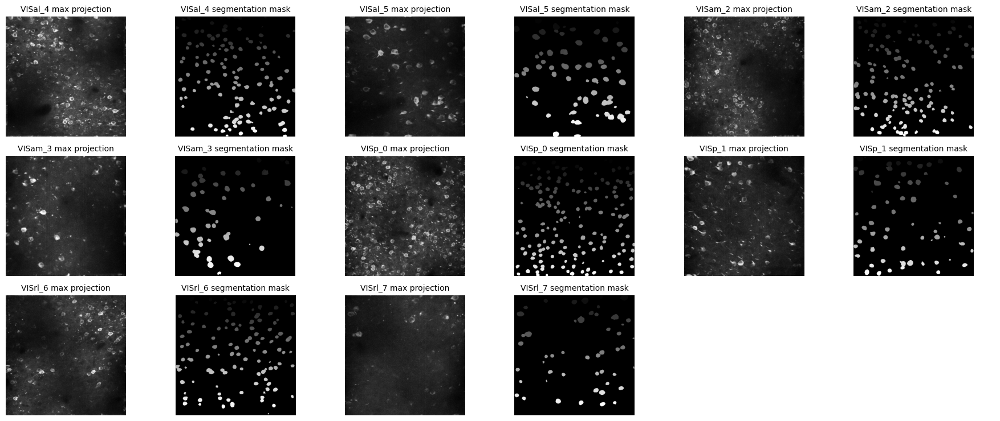

In [47]:
n_planes = len(plane_items)
if n_planes == 0:
    print("No planes with images found.")
else:
    # Set number of columns of pairs
    n_cols = 3  # each column will be a pair of images
    n_rows = ceil(n_planes / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols * 2, figsize=(6 * n_cols, 2.5 * n_rows))
    
    # Ensure axes is always 2D
    if n_rows == 1:
        axes = axes.reshape(1, n_cols * 2)

    # Flatten axes for easy indexing
    axes = axes.flatten()

    for idx, (plane_name, (max_proj, seg_mask)) in enumerate(plane_items.items()):
        # Left image of pair
        ax_left = axes[idx * 2]
        ax_left.imshow(max_proj, cmap='gray')
        ax_left.axis('off')
        ax_left.set_title(f"{plane_name} max projection", fontsize=10)

        # Right image of pair
        ax_right = axes[idx * 2 + 1]
        ax_right.imshow(seg_mask, cmap='gray')
        ax_right.axis('off')
        ax_right.set_title(f"{plane_name} segmentation mask", fontsize=10)

    # Turn off any unused axes
    for ax in axes[n_planes * 2:]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()


### Extracting ROI Fluorescence
Below the 2-Photon Fluorescence data is extracted for a chosen plane. The raw fluorescence is normalized into DF/F % in order to eliminate sources of noise and day-to-day variability. The plane's `dff_trace` is a 2D pulled from the files which contain these recordings over time throughout the session for each ROI. It should have a shape (n_measurments x n_rois). It is associated with its `dff_timestamps` array, with shape (n_measurements), which records the timestamp at which each measurement was taken. With these we can plot one plane's fluorescence across the whole session

In [48]:
selected_plane = "VISp_0"

dff = nwb.processing[selected_plane]["dff_timeseries"]["dff_timeseries"]
dff_trace = np.array(dff.data)
dff_timestamps = np.array(dff.timestamps)

print(dff_trace.shape)
print(dff_timestamps.shape)

avg_dff_trace = np.average(dff_trace, axis=1)

(44380, 160)
(44380,)


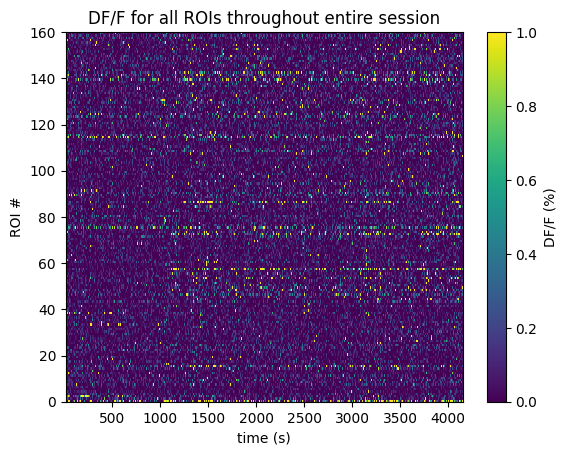

In [49]:
%matplotlib inline
n_rois = dff_trace.shape[1]
plt.imshow(dff_trace.transpose(), extent=[dff_timestamps[0], dff_timestamps[-1], 0, n_rois], aspect='auto', vmin=0, vmax=1, interpolation='None')
# plt.yticks(np.arange(n_rois)+0.5, np.arange(n_rois))
plt.ylabel("ROI #")
plt.xlabel("time (s)")
plt.title("DF/F for all ROIs throughout entire session")
cbar = plt.colorbar()
cbar.set_label('DF/F (%)')


### Session Timeline
To get a good idea of the order and the way stimulus is shown throughout the session, the code below generates a timeline of the various 'epochs' of stimulus. The different kinds of stimulus are stored in several `intervals` tables in the nwb, which each contain the associated timing and stimulus parameters for that stimulus.


**Importantly**, the way we ran stimulus for this experiment is such that multiple 'intervals' blocks were actually being run simultaneously to produce the desired stimulus. Therefore, the tables `ShapeStim_presentations`, `rdkCircle_presentations`, and `rdkSqr_presentations` should have the same timing and number of rows. And in the epochs plot below, the epochs for these should overlap and be displayed as one block.


In [50]:
for stim_table_name in nwb.intervals.keys():
	print(stim_table_name)

ShapeStim_presentations
drifting_gratings_field_block_presentations
homogeneous_background_presentations
rdkCircle_presentations
rdkSqr_presentations
receptive_field_block_presentations
spontaneous_presentations


In [51]:
# extract epoch times from stim table where stimulus rows have a different 'block' than following row
# returns list of epochs, where an epoch is of the form (stimulus name, stimulus block, start time, stop time)
def extract_epochs_from_table(stim_name, stim_table, epochs):
    
    # specify a current epoch stop and start time
    epoch_start = stim_table.start_time[0]
    epoch_stop = stim_table.stop_time[0]

    # for each row, try to extend current epoch stop_time
    for i in range(len(stim_table)):
        this_block = stim_table.stim_block[i]
        # if end of table, end the current epoch
        if i+1 >= len(stim_table):
            epochs.append((stim_name, this_block, epoch_start, epoch_stop))
            break
            
        next_block = stim_table.stim_block[i+1]
        # if next row is the same stim block, push back epoch_stop time
        if next_block == this_block:
            epoch_stop = stim_table.stop_time[i+1]
        # otherwise, end the current epoch, start new epoch
        else:
            epochs.append((stim_name, this_block, epoch_start, epoch_stop))
            epoch_start = stim_table.start_time[i+1]
            epoch_stop = stim_table.stop_time[i+1]
    
    return epochs

In [52]:
def extract_all_epochs(nwb):
    # extract epochs from all valid stimulus tables
    epochs = []
    for stim_name in nwb.intervals.keys():
        print(stim_name)
        stim_table = nwb.intervals[stim_name]
        try:
            epochs = extract_epochs_from_table(stim_name, stim_table, epochs)
        except:
            continue
    return epochs

In [53]:
%matplotlib inline
### make plot of chosen trace over time with colored epoch sections

def plot_trace_over_epochs(trace_arrs, timestamps_arrs, epochs, time_start=None, time_end=None, title=None, trace_labels=None, yaxlabels=None, xlabel=None):
    assert len(trace_arrs) == len(timestamps_arrs), "there must be an equal number of traces and timestamps arrays"
    if trace_labels is not None:
        assert len(trace_arrs) == len(trace_labels), "there must be an equal number of traces and trace labels arrays"
    if yaxlabels is not None:
        assert len(trace_arrs) == len(yaxlabels),  "there must be an equal number of traces and y-axis labels arrays"

    fig, ax = plt.subplots(figsize=(15,5), dpi=300)
    if time_start is None:
        time_start = np.min(np.concatenate(timestamps_arrs))
    if time_end is None:
        time_end = np.max(np.concatenate(timestamps_arrs))

    # filter epochs which aren't at least partially in the time window
    bounded_epochs = {epoch for epoch in epochs if epoch[2] < time_end and epoch[3] > time_start}

    # assign unique color to each stimulus name
    stim_names = list({epoch[0] for epoch in bounded_epochs})
    colors = plt.cm.rainbow(np.linspace(0,1,len(stim_names)))
    stim_color_map = {stim_names[i]:colors[i] for i in range(len(stim_names))}

    key = {}
    
    y_hi = np.max(np.concatenate(trace_arrs)) # change these to manually set height of the plot
    y_lo = np.min(np.concatenate(trace_arrs))
    # draw colored rectangles for each epoch
    for epoch in bounded_epochs:
        stim_name, stim_block, epoch_start, epoch_end = epoch
        color = stim_color_map[stim_name]
        rec = ax.add_patch(mpl.patches.Rectangle((epoch_start, y_lo), epoch_end-epoch_start, 100, alpha=0.3, facecolor=color, antialiased=False))
        key[(stim_name)] = rec

    ax.set_xlim(time_start, time_end)
    ax.set_ylim(y_lo, y_hi)
    if xlabel is not None:
        ax.set_xlabel(xlabel)
    if title is not None:
        ax.set_title(title)
    if yaxlabels is not None:
        ax.set_ylabel("\n".join(yaxlabels))

    for i in range(len(trace_arrs)):
        # next_color = plt.rcParams["axes.prop_cycle"].by_key()["color"][i]
        # this_ax = ax.twinx()
        line = ax.plot(timestamps_arrs[i], trace_arrs[i])[0]
        if trace_labels is not None:
            key[(trace_labels[i])] = line

    print(key)
    fig.legend(key.values(), key.keys(), loc="lower right", bbox_to_anchor=(1.25, 0.25))
    
    return ax

In [54]:
epochs = extract_all_epochs(nwb)

# epochs take the form (stimulus name, stimulus block, start time, stop time)
print("Num epochs:",len(epochs))
epochs.sort(key=lambda x: x[2])
for epoch in epochs:
    print(epoch)

# can set these manually to get a closer look at the timeline
time_start = min(epochs, key=lambda epoch: epoch[1])[1]
time_end = max(epochs, key=lambda epoch:epoch[2])[2]
# time_start = 3000
# time_end = 3100

# can set this to change what trace is displayed alongside epochs
display_trace = avg_dff_trace * 100 # to yield percentage
# unit_idx = 30
# display_trace = dff_trace[:,unit_idx] * 100

ShapeStim_presentations
drifting_gratings_field_block_presentations
homogeneous_background_presentations
rdkCircle_presentations
rdkSqr_presentations
receptive_field_block_presentations
spontaneous_presentations
Num epochs: 6
('receptive_field_block_presentations', '0.0', 18.02844874757282, 738.6263787475727)
('drifting_gratings_field_block_presentations', '1.0', 748.6346887475728, 868.2339587475727)
('homogeneous_background_presentations', '2.0', 988.8340587475728, 1109.901258747573)
('ShapeStim_presentations', '4.0', 1109.901258747573, 4147.923608747573)
('rdkCircle_presentations', '5.0', 1109.901258747573, 4147.923608747573)
('rdkSqr_presentations', '3.0', 1109.901258747573, 4147.923608747573)


{'drifting_gratings_field_block_presentations': <matplotlib.patches.Rectangle object at 0x000001DD5D0F3220>, 'rdkSqr_presentations': <matplotlib.patches.Rectangle object at 0x000001DD5B122500>, 'ShapeStim_presentations': <matplotlib.patches.Rectangle object at 0x000001DD5B123D90>, 'homogeneous_background_presentations': <matplotlib.patches.Rectangle object at 0x000001DD6F2BB4C0>, 'receptive_field_block_presentations': <matplotlib.patches.Rectangle object at 0x000001DD55C21030>, 'rdkCircle_presentations': <matplotlib.patches.Rectangle object at 0x000001DD55C21A80>, 'avg dff': <matplotlib.lines.Line2D object at 0x000001DD56CA59C0>}


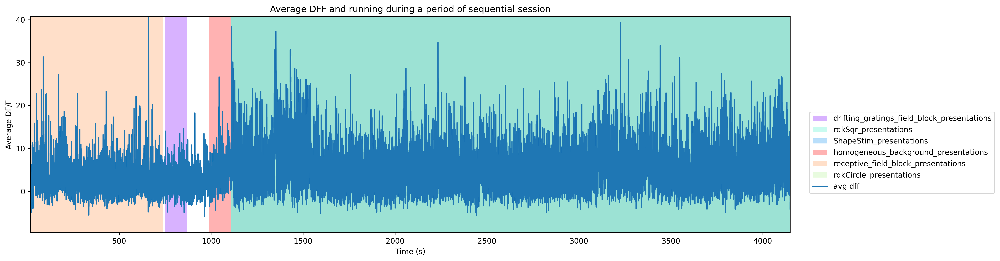

In [55]:
# adjust these to zoom in to a narrow slice of time
start, stop = None, None
ax = plot_trace_over_epochs([display_trace], [dff_timestamps], epochs, start, stop, "Average DFF and running during a period of sequential session", ['avg dff'], ["Average DF/F"], "Time (s)")
plt.tight_layout()
plt.show()

## Example: responses to full‑field dots

In the following, we examine direction tuning in V1 for a full‑field random‑dot kinematogram stimulus at 100% coherence (all dots move in a single direction).

For this, we (1) extract and interpolate dF/F traces, (2) align responses to selected dot motion stimulus onsets, and (3) plot trial‑by‑trial responses and tuning curves for selected ROIs.

### Extracting and interpolating dF/F traces

We first extract dF/F traces for one imaging plane in V1 and interpolate them onto a uniform time grid. This makes it easy to align responses across trials in later steps.

In [56]:
def interpolate_dff(dff_trace, timestamps, interp_hz):
    """Interpolate dF/F traces onto a regular time grid at interp_hz."""
    time_axis = np.arange(timestamps[0], timestamps[-1], step=1.0 / interp_hz)
    interp_dff = []

    # interpolate channel by channel to save RAM
    for channel in range(dff_trace.shape[1]):
        f = interpolate.interp1d(timestamps, dff_trace[:, channel], axis=0, kind="nearest", fill_value="extrapolate")
        interp_dff.append(f(time_axis))
    interp_dff = np.asarray(interp_dff).T

    return interp_dff, time_axis


def get_dff(nwb, plane, interpolating=True):
    """Return dF/F and timestamps for one imaging plane."""
    series = nwb.processing[plane].data_interfaces["dff_timeseries"].roi_response_series[
        "dff_timeseries"
    ]
    timestamps = series.timestamps[:]
    dff = series.data[:]

    if interpolating:
        interp_hz = nwb.imaging_planes[plane].imaging_rate
        dff, timestamps = interpolate_dff(dff, timestamps, interp_hz)

    return dff, timestamps

In [57]:
plane = "VISp_0"
interpolating = True

dff, timestamps = get_dff(nwb, plane, interpolating=interpolating)
print(dff.shape)

(43917, 160)


### Selecting Stimulus Times


Next, we collect stimulus presentation indices for full‑field dot RDKs with 100% coherence, across all motion directions.

The dot stimulus is described by two intervals tables:
stim_table_sqr (surround dots) and stim_table_circle (center dots).

We use the opacity field in both tables to distinguish configurations:
- Full‑field dots: square opacity = "1.0" and circle opacity = "0.0".
- Center‑only: square opacity = "0.0", circle opacity = "1.0".
- Center + surround: both opacities = "1.0".

FieldCoherence = "1.0" means all dots move coherently in the same direction, "0.0" is fully random motion.

In [58]:
# obtain the stimulus presentation times for the random dot kinematograms
rdkCir_presentations = nwb.intervals["rdkCircle_presentations"].to_dataframe()
rdkSqr_presentations = nwb.intervals["rdkSqr_presentations"].to_dataframe()
rdk_presentations = pd.merge(rdkCir_presentations, rdkSqr_presentations, on=['start_time', 'stop_time'], how='outer', suffixes=('_Circle', '_Sqr'))

full_field_rdk_presentations = rdk_presentations[
    (rdk_presentations['opacity_Circle'] == '0.0') & 
    (rdk_presentations['opacity_Sqr'] == '1.0') & 
    (rdk_presentations['FieldCoherence_Sqr'] == '1.0')
]

full_field_rdk_presentations.head()

,start_time,stop_time,stim_name_Circle,stim_type_Circle,stim_block_Circle,stim_index_Circle,Dir_Circle,opacity_Circle,FieldCoherence_Circle,dotSize_Circle,...,stim_index_Sqr,Dir_Sqr,opacity_Sqr,FieldCoherence_Sqr,dotSize_Sqr,speed_Sqr,fieldSize_Sqr,dotDensity_Sqr,tags_Sqr,timeseries_Sqr
1,1111.402479,1112.403299,rdkCircle,FixedDotStim,5.0,5.0,0.0,0.0,1.0,40.0,...,3.0,45.0,1.0,1.0,40.0,10.0,2000.0,0.0003,[stimulus_time_interval],"[(2962, 1, timestamps pynwb.base.TimeSeries at..."
19,1138.424919,1139.425739,rdkCircle,FixedDotStim,5.0,5.0,0.0,0.0,1.0,40.0,...,3.0,225.0,1.0,1.0,40.0,10.0,2000.0,0.0003,[stimulus_time_interval],"[(2980, 1, timestamps pynwb.base.TimeSeries at..."
35,1162.444859,1163.445679,rdkCircle,FixedDotStim,5.0,5.0,270.0,0.0,1.0,40.0,...,3.0,270.0,1.0,1.0,40.0,10.0,2000.0,0.0003,[stimulus_time_interval],"[(2996, 1, timestamps pynwb.base.TimeSeries at..."
41,1171.452369,1172.453179,rdkCircle,FixedDotStim,5.0,5.0,0.0,0.0,1.0,40.0,...,3.0,135.0,1.0,1.0,40.0,10.0,2000.0,0.0003,[stimulus_time_interval],"[(3002, 1, timestamps pynwb.base.TimeSeries at..."
50,1184.963549,1185.964409,rdkCircle,FixedDotStim,5.0,5.0,0.0,0.0,1.0,40.0,...,3.0,315.0,1.0,1.0,40.0,10.0,2000.0,0.0003,[stimulus_time_interval],"[(3011, 1, timestamps pynwb.base.TimeSeries at..."


In [59]:
full_field_rdk_presentations["Dir_Sqr"].unique()

array(['45.0', '225.0', '270.0', '135.0', '315.0', '90.0', '0.0', '180.0'],
      dtype=object)

### Generating Response Windows

Now we use dF/F traces to find all trial‑aligned windows around each stimulus onset, grouped by motion direction. To match the stimulus presentation frequency, each window spans from 0.5 seconds before stimulus onset to 1 second after. We add a delay of 0.2s to account for the indicator decay time.

In [60]:
onset_delay = 0.2
window_pre = 0.5

resp_windows_by_dir = {}
for dir in np.sort(full_field_rdk_presentations['Dir_Sqr'].astype(float).unique()):
    dir_df = full_field_rdk_presentations[full_field_rdk_presentations['Dir_Sqr'] == str(dir)]

    resp_windows = []
    for idx, row in dir_df.iterrows():
        window_start_idx, window_end_idx = np.searchsorted(timestamps, row['start_time'] + onset_delay - window_pre), np.searchsorted(timestamps, row['stop_time'] + onset_delay)
        resp_window = dff[window_start_idx:window_end_idx, :].transpose(1, 0) # window size x n_rois
        resp_windows.append(resp_window)
    
    min_len = min([rw.shape[1] for rw in resp_windows]) # take the minimum length of all response windows to avoid shape mismatch
    resp_windows = np.stack([rw[:, :min_len] for rw in resp_windows], axis=0)
    resp_windows_by_dir[dir] = resp_windows


### Showing Response Windows 

For each ROI and motion direction, we generate a trial-by-time heatmap of aligned responses. show_rois_by_condition extends show_dff_response by organizing these plots into a grid with ROIs as rows and motion directions as columns.

In [61]:
def show_dff_response(ax, dff, window_start_time, window_end_time, aspect="auto", vmin=None, vmax=None, yticklabels=[], skipticks=1, xlabel="Time (s)", ylabel="ROI", cbar=True, cbar_label=None):
    if len(dff) == 0:
        print("Input data has length 0; Nothing to display")
        return

    img = ax.imshow(dff, aspect=aspect, extent=[window_start_time, window_end_time, 0, len(dff)], vmin=vmin, vmax=vmax)
    if cbar:
        ax.colorbar(img, shrink=0.5, label=cbar_label)

    ax.plot([0,0],[0, len(dff)], ":", color="white", linewidth=1.0)

    if len(yticklabels) != 0:
        ax.set_yticks(range(len(yticklabels)))
        ax.set_yticklabels(yticklabels, fontsize=8)

        n_ticks = len(yticklabels[::skipticks])
        ax.yaxis.set_major_locator(plt.MaxNLocator(n_ticks))

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

In [62]:
def show_rois_by_dir(resp_windows_by_dir, window_start_time, window_end_time, vmin=None, vmax=None, cbar_label=None, roi_idxs=None, suptitle=None
):
    """Plot rois x conditions with one colorbar per row."""
    dirs = list(resp_windows_by_dir.keys())
    n_rois = resp_windows_by_dir[dirs[0]].shape[1]
    n_dirs = len(dirs)

    if roi_idxs is None:
        roi_idxs = list(range(n_rois))
    n_rois_to_plot = len(roi_idxs)

    fig, axes = plt.subplots(n_rois_to_plot, n_dirs, figsize=(2*n_dirs, 1.5*n_rois_to_plot), squeeze=False, layout="constrained")
    low_q, high_q = 2, 98  # or 5, 95

    if vmin is None or vmax is None:
        row_vmin, row_vmax = [], []
        for r_idx_data in roi_idxs:
            vals = np.concatenate([resp_windows_by_dir[dir][:, r_idx_data, :].ravel() for dir in dirs])
            row_vmin.append(np.nanpercentile(vals, low_q))
            row_vmax.append(np.nanpercentile(vals, high_q))

        if row_vmax[-1] <= row_vmin[-1]:
            row_vmax[-1] = row_vmin[-1] + 1e-6    
    else:    
        row_vmin = [vmin] * n_rois_to_plot
        row_vmax = [vmax] * n_rois_to_plot

    for c_idx, dir in enumerate(dirs):
        for r_idx_plot, r_idx_data in enumerate(roi_idxs):
            ax = axes[r_idx_plot, c_idx]
            dff = resp_windows_by_dir[dir][:, r_idx_data, :]

            this_vmin = row_vmin[r_idx_plot]
            this_vmax = row_vmax[r_idx_plot]

            show_dff_response(
                ax, dff,
                window_start_time, window_end_time,
                xlabel="Time (frames)" if r_idx_plot == n_rois_to_plot-1 else None,
                ylabel="Trials" if c_idx == 0 else None,
                cbar=False,
                vmin=this_vmin, vmax=this_vmax,
            )

            if r_idx_plot == 0:
                ax.set_title(f"{float(dir):.0f}°", fontsize=11, pad=10)
            if c_idx == 0:
                ax.set_ylabel(f"ROI {r_idx_data}\nTrials")

    for r_idx_plot in range(n_rois_to_plot):
        norm = mpl.colors.Normalize(vmin=row_vmin[r_idx_plot], vmax=row_vmax[r_idx_plot])
        fig.colorbar(
            mpl.cm.ScalarMappable(norm=norm),
            ax=axes[r_idx_plot, :],
            orientation='vertical',
            shrink=0.6, pad=0.02,
            label=cbar_label,
        )

    if suptitle is not None:
        fig.suptitle(suptitle, fontsize=12)

    return fig, axes

For plotting examples, we select ROIs with the largest difference in trial‑averaged response between their preferred direction and all other directions.

In [63]:
# simple heuristic to select cells to plot
def select_top_rois_tuning_ampl(windows, pre_n=5, on_n=10, top_k=10):
    """Score ROIs by direction-tuning prominence and return the top_k indices.
    Uses (on - pre) responses per direction; score = peak direction minus mean of other directions.
    """
    per_dir_means = []  # list of (cells,) arrays

    for w in windows:
        n_time = w.shape[-1]
        pre = w[:, :, :min(pre_n, n_time // 2)].mean(-1)       
        on  = w[:, :, -min(on_n, n_time // 2):].mean(-1)      
        delta_mean = (on - pre).mean(axis=0)                   
        per_dir_means.append(delta_mean)

    mean_dir = np.stack(per_dir_means, axis=0)                 

    peak = mean_dir.max(axis=0)                                
    peak_dir = mean_dir.argmax(axis=0)                         

    mean_other = (mean_dir.sum(axis=0) - peak) / (mean_dir.shape[0] - 1)
    prominence = peak - mean_other                             
    # require positive peak response
    prominence[peak <= 0] = -np.inf

    idx = np.argsort(prominence)[-top_k:][::-1]
    return idx, prominence

In [64]:
roi_idxs, _ = select_top_rois_tuning_ampl(resp_windows_by_dir.values(), top_k=10)
print("Selected ROIs:", roi_idxs)

Selected ROIs: [ 73 106 159 127  52  57 144  86 110  23]


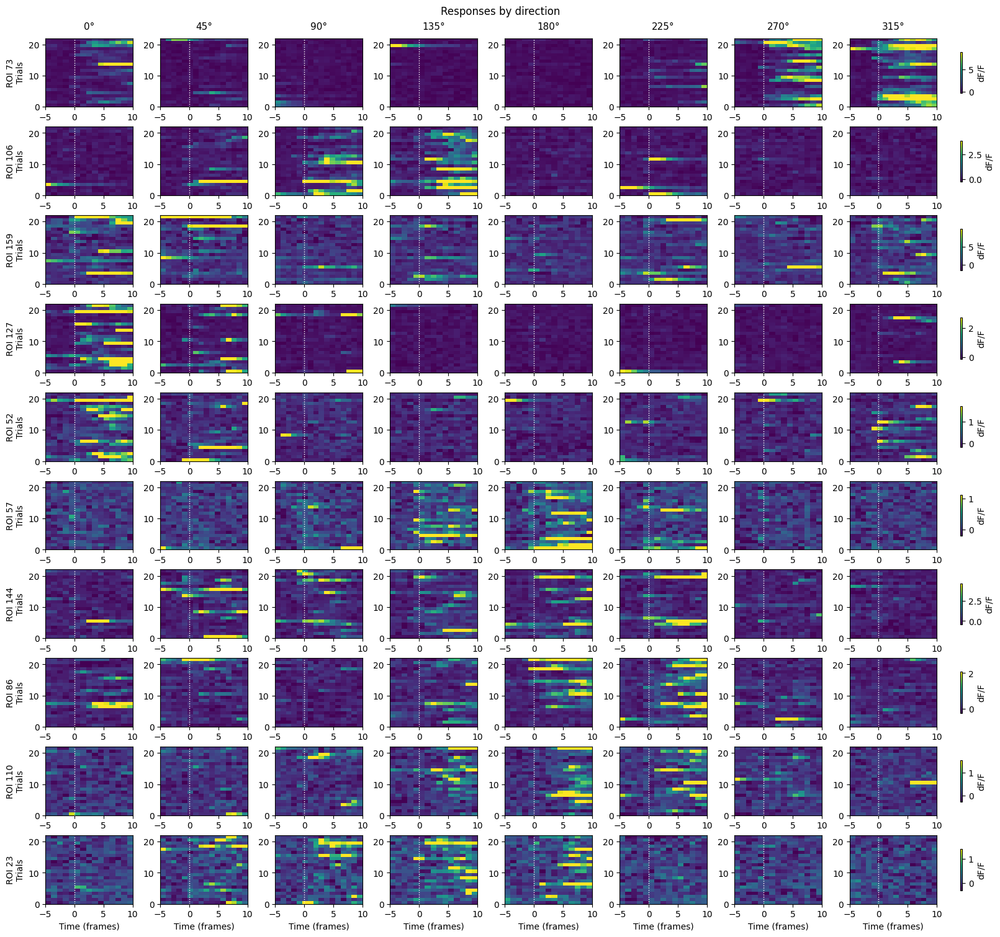

In [65]:
fig, axes = show_rois_by_dir(
    resp_windows_by_dir=resp_windows_by_dir,
    window_start_time=-5,             
    window_end_time=10,                
    vmin=None,                          
    vmax=None,
    cbar_label="dF/F",
    roi_idxs=roi_idxs,
    suptitle="Responses by direction",
)

In V1, we find many cells that are reliably responsive to full-screen random dot kinematogram stimuli, with clear preferences for certain motion directions. 
The following tuning curves further show this.

### Plot direction tuning curves

For each selected ROI, we scatter the time-averaged responses per direction and plot the mean across directions over trials.

In [66]:
def plot_tuning_curves(
    resp_windows_by_dir,
    roi_indices,
    on_n_frames=5,
    n_rows=2,
    n_cols=3,
):
    """Plot tuning curves with trial scatter and per-ROI 98th percentile clipping."""
    directions_deg = list(resp_windows_by_dir.keys())
    roi_indices = list(roi_indices)

    n_cells = resp_windows_by_dir[directions_deg[0]].shape[1]
    n_plots = min(len(roi_indices), n_rows * n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 3 * n_rows), sharex=True, squeeze=False)
    axes = axes.ravel()
    for ax in axes[n_plots:]:
        ax.set_visible(False)

    color_mean = "black"
    color_dots = "gray"

    for plot_idx, roi_idx in enumerate(roi_indices[:n_plots]):
        ax = axes[plot_idx]
        if roi_idx >= n_cells:
            ax.set_visible(False)
            continue

        means_per_dir = []
        all_vals = []
        dir_maxes = []
        dir_vals = []

        for dir in directions_deg:
            w = resp_windows_by_dir[dir]
            if roi_idx >= w.shape[1]:
                continue
            n_time = w.shape[-1]
            on_n = min(on_n_frames, n_time)
            trial_vals = w[:, roi_idx, -on_n:].mean(axis=-1)
            means_per_dir.append(trial_vals.mean())
            all_vals.append(trial_vals)
            dir_maxes.append(trial_vals.max())
            dir_vals.append(dir)
            ax.scatter(np.full_like(trial_vals, dir_vals[-1], dtype=float), trial_vals, color=color_dots, s=15, alpha=0.3)

        if all_vals:
            all_vals = np.concatenate(all_vals)
            y_max = np.nanpercentile(all_vals, 98)
            ax.set_ylim(top=y_max * 1.05)
            for dv, dmax in zip(dir_vals, dir_maxes):
                if dmax > y_max:
                    ax.scatter(dv, y_max, marker="^", color=color_dots, s=25)

        means_per_dir = np.asarray(means_per_dir)
        ax.plot(directions_deg, means_per_dir, "o-", color=color_mean, linewidth=2)
        ax.axhline(0, color="gray", linestyle=":", linewidth=0.8)
        ax.set_title(f"ROI {roi_idx}")
        ax.set_xticks(list(resp_windows_by_dir.keys()))
        if plot_idx // n_cols == n_rows - 1:
            ax.set_xlabel("Direction (°)")
        if plot_idx % n_cols == 0:
            ax.set_ylabel("Response (dF/F)")

    plt.tight_layout()
    return fig

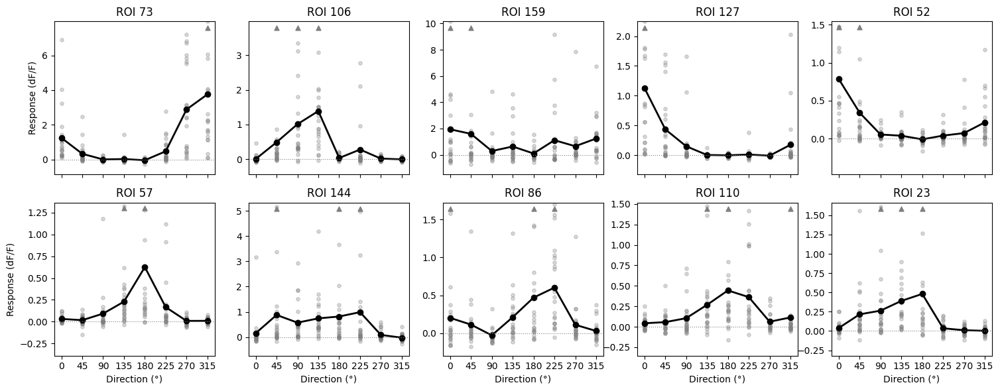

In [67]:
n_cols = 5
n_rows = roi_idxs.size // n_cols
fig = plot_tuning_curves(resp_windows_by_dir, roi_idxs, on_n_frames=10, n_rows=n_rows, n_cols=n_cols)

### Responsiveness Analysis

To determine whether a neuron is responsive to a stimulus, we compare activity during the pre-stimulus period with activity during stimulus presentation. Specifically, we take the 0.5-second gray period preceding each stimulus as the baseline distribution and compare it to the distribution of responses during the stimulus epoch.

The Wilcoxon rank-sum test is used for this comparison. This nonparametric test evaluates whether the two sets of responses are likely drawn from the same distribution (null hypothesis) or from different distributions. A significant result indicates that stimulus-evoked activity differs from baseline activity, suggesting responsiveness.

In [68]:
# compute the pre-stimulus and during-stimulus responses for each stimulus presentation
pre_stim_start_time = -5 # in frames
indicator_delay = 2 # in frames

def compute_pre_and_during_stimulus_response(row):
    assert pre_stim_start_time < 0, "pre_stim_start_time must be negative"
    stim_start_idx, stim_stop_idx = np.searchsorted(dff_timestamps, row['start_time']) + indicator_delay, np.searchsorted(dff_timestamps, row['stop_time']) + indicator_delay
    pre_stim_resp = dff_trace[stim_start_idx+pre_stim_start_time:stim_start_idx].mean(axis=0)
    stim_resp = dff_trace[stim_start_idx:stim_stop_idx].mean(axis=0)
    return pd.Series([pre_stim_resp, stim_resp])

rdk_presentations[['pre_stim_resp', 'stim_resp']] = rdk_presentations.apply(compute_pre_and_during_stimulus_response, axis=1)

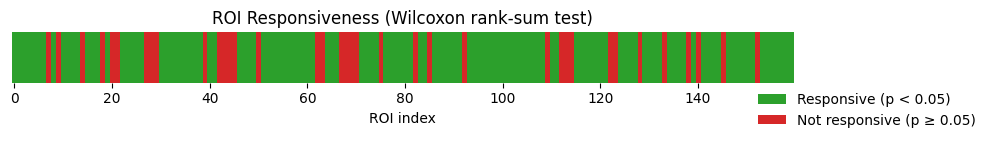

In [69]:
# use the wilcoxon rank-sum test to compare the pre-stimulus responses and during-stimulus responses
pre_stim_resp = np.vstack(rdk_presentations['pre_stim_resp'].values)
stim_resp = np.vstack(rdk_presentations['stim_resp'].values)

p_vals = np.array([
    mannwhitneyu(stim_resp[:, i], pre_stim_resp[:, i], alternative='greater').pvalue
    for i in range(stim_resp.shape[1])
])

# Define responsiveness
responsive = p_vals < 0.05
cmap = ListedColormap(['tab:red', 'tab:green'])

fig, ax = plt.subplots(figsize=(10, 1.5))

ax.imshow(responsive[np.newaxis, :], aspect='auto', cmap=cmap)
ax.set_yticks([])
ax.set_xlabel('ROI index')
ax.set_title('ROI Responsiveness (Wilcoxon rank-sum test)')
for spine in ax.spines.values():
    spine.set_visible(False)
legend_elements = [
    Patch(facecolor='tab:green', edgecolor='none', label='Responsive (p < 0.05)'),
    Patch(facecolor='tab:red', edgecolor='none', label='Not responsive (p ≥ 0.05)')
]
ax.legend(handles=legend_elements, loc='upper right', frameon=False, bbox_to_anchor=(1.25, 0.05))

plt.tight_layout()
plt.show()

### Receptive Fields

First, we determine the dimensions of the receptive field plots from the set of possible coordinates of the Gabor patch stimulus. Next, for each coordinate, we compute the unit’s fluorescnece response (i.e. ΔF/F) within a defined time window following stimulus onset. The responses are averaged across trials for each stimulus position to obtain a single response value per coordinate.

Finally, for each unit, the trial-averaged calcium responses are arranged according to the spatial layout of the stimulus grid and plotted as a 2D array, where each pixel represents the mean calcium activity evoked by the stimulus at that location.

In [70]:
rf_block_presentations = nwb.intervals["receptive_field_block_presentations"].to_dataframe()

def compute_stim_response(row):
    stim_start_idx = np.searchsorted(dff_timestamps, row['start_time'] + onset_delay)
    stim_stop_idx = np.searchsorted(dff_timestamps, row['stop_time'] + onset_delay)
    
    return dff_trace[stim_start_idx:stim_stop_idx].mean(axis=0)

rf_block_presentations['resp'] = rf_block_presentations.apply(compute_stim_response, axis=1)

In [71]:
resps = np.vstack(rf_block_presentations['resp'].values)
nrois = resps.shape[1]

# create receptive field maps
unique_x = np.sort(np.unique(rf_block_presentations['x_position'].astype(float)))
unique_y = np.sort(np.unique(rf_block_presentations['y_position'].astype(float)))

receptive_fields = np.zeros((nrois, len(unique_y), len(unique_x)))
stim_counts = np.zeros((len(unique_y), len(unique_x)))
for i, row in rf_block_presentations.iterrows():
    x_pos = float(row['x_position'])
    y_pos = float(row['y_position'])

    x_idx = np.argmin(np.abs(unique_x - x_pos))
    y_idx = np.argmin(np.abs(unique_y - y_pos))

    resp = row['resp']
    receptive_fields[:, y_idx, x_idx] += resp  # No need for [:, None]
    stim_counts[y_idx, x_idx] += 1

receptive_fields /= stim_counts[None, :, :]

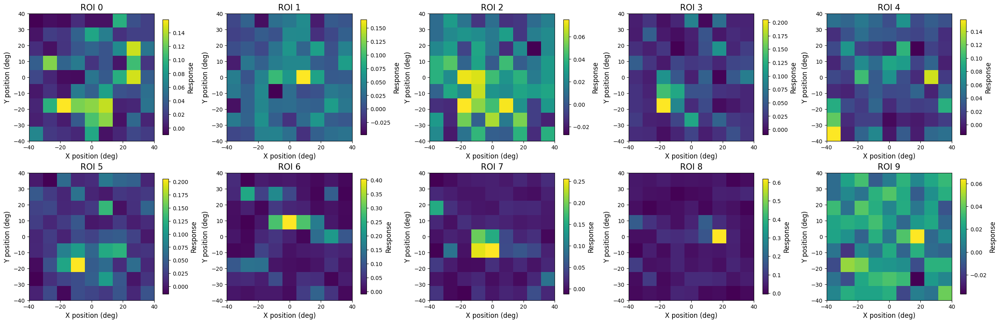

In [72]:
nrows, ncols = 2, 5
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*5, nrows*4), constrained_layout=True)
axes = axes.ravel()

for i in range(nrows*ncols):
    ax = axes[i]
    roi_idx = i
    im = ax.imshow(
        receptive_fields[roi_idx],
        extent=[float(unique_x.min()), float(unique_x.max()), float(unique_y.min()), float(unique_y.max())],
        aspect='auto',
        origin='upper'
    )
    ax.set_title(f"ROI {roi_idx}", fontsize=15)
    ax.set_xlabel("X position (deg)", fontsize=12)
    ax.set_ylabel("Y position (deg)", fontsize=12)
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Response', fontsize=12)


plt.show()